In [1]:
import pandas as pd
import numpy as np
import os

from catboost import CatBoostClassifier

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname,filename))

/kaggle/input/competitions/playground-series-s6e9/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e9/train.csv
/kaggle/input/competitions/playground-series-s6e9/test.csv


In [3]:
pd.set_option('display.max_columns',None)

In [4]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e9/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e9/test.csv")
submission = pd.read_csv("/kaggle/input/competitions/playground-series-s6e9/sample_submission.csv")

In [5]:
train

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,668660,30,71090.0,27.4,2,5,6,5.0,Male,Urban,Sedan,No,Yes,Medium,No
668661,668661,32,129990.0,5.0,2,5,4,1.0,Female,Suburban,SUV,Yes,Yes,Low,No
668662,668662,64,121791.0,24.2,1,5,6,1.0,Female,Suburban,Hatchback,Yes,Yes,Low,No
668663,668663,51,115923.0,43.7,2,0,0,1.0,Female,Rural,SUV,Yes,Yes,Low,No


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  object 
 9   City_Type                    668665 non-null  object 
 10  Current_Car_Type             668665 non-null  object 
 11  Home_Charging_Possible       668665 non-null  object 
 12  Subsidy_Available            668665 non-null  object 
 13 

In [7]:
train.isna().sum().sum()

np.int64(0)

In [8]:
train.describe()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level
count,668665.00000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000
mean,334332.00000,47.039171,84769.266989,32.158298,1.712626,4.960408,7.176314,2.935477
std,193027.10321,12.875448,28648.029042,18.730474,0.729275,3.926843,5.186627,1.429119
min,0.00000,25.000000,30000.000000,5.000000,1.000000,0.000000,0.000000,1.000000
25%,167166.00000,36.000000,67376.000000,17.200000,1.000000,2.000000,3.000000,2.000000
50%,334332.00000,47.000000,84880.000000,33.600000,2.000000,4.000000,6.000000,3.000000
75%,501498.00000,58.000000,102753.000000,47.400000,2.000000,7.000000,10.000000,4.000000
max,668664.00000,69.000000,188549.000000,98.700000,4.000000,14.000000,19.000000,5.000000


In [9]:
test

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level
0,668665,61,67725.0,16.9,2,7,4,4.0,Male,Suburban,Sedan,Yes,No,Low
1,668666,42,152835.0,41.9,2,9,9,4.0,Male,Urban,SUV,No,No,Low
2,668667,68,86877.0,53.3,1,10,11,4.0,Female,Urban,Sedan,No,No,Low
3,668668,39,46794.0,34.1,2,4,8,4.0,Female,Suburban,Sedan,Yes,No,Low
4,668669,55,112172.0,57.2,1,6,4,1.0,Female,Suburban,Sedan,Yes,Yes,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286566,955231,63,75830.0,23.9,1,3,3,1.0,Male,Suburban,SUV,Yes,No,Low
286567,955232,27,79563.0,55.2,2,7,5,3.0,Male,Suburban,Sedan,Yes,Yes,Low
286568,955233,30,48183.0,42.6,3,7,7,4.0,Female,Suburban,Sedan,Yes,No,Low
286569,955234,32,107845.0,5.0,2,14,7,1.0,Female,Urban,SUV,No,No,Low


In [10]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286571 entries, 0 to 286570
Data columns (total 14 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           286571 non-null  int64  
 1   Age                          286571 non-null  int64  
 2   Annual_Income_USD            286571 non-null  float64
 3   Daily_Commute_km             286571 non-null  float64
 4   Number_of_Cars_Owned         286571 non-null  int64  
 5   Charging_Stations_Near_Home  286571 non-null  int64  
 6   Charging_Stations_Near_Work  286571 non-null  int64  
 7   Environmental_Concern_Level  286571 non-null  float64
 8   Gender                       286571 non-null  object 
 9   City_Type                    286571 non-null  object 
 10  Current_Car_Type             286571 non-null  object 
 11  Home_Charging_Possible       286571 non-null  object 
 12  Subsidy_Available            286571 non-null  object 
 13 

In [11]:
test.isna().sum().sum()

np.int64(0)

In [12]:
test.describe()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level
count,286571.000000,286571.000000,286571.000000,286571.000000,286571.000000,286571.000000,286571.000000,286571.000000
mean,811950.000000,47.070824,84799.508432,32.159305,1.716095,4.950693,7.155626,2.934554
std,82726.066333,12.864850,28626.851098,18.724436,0.731088,3.928626,5.186880,1.427541
min,668665.000000,25.000000,30000.000000,5.000000,1.000000,0.000000,0.000000,1.000000
25%,740307.500000,36.000000,67380.000000,17.200000,1.000000,2.000000,3.000000,2.000000
50%,811950.000000,47.000000,84926.000000,33.600000,2.000000,4.000000,6.000000,3.000000
75%,883592.500000,58.000000,102751.000000,47.300000,2.000000,7.000000,10.000000,4.000000
max,955235.000000,69.000000,186936.000000,103.900000,4.000000,14.000000,19.000000,5.000000


In [13]:
submission

,id,Will_Buy_EV
0,668665,0.174645
1,668666,0.174645
2,668667,0.174645
3,668668,0.174645
4,668669,0.174645
...,...,...
286566,955231,0.174645
286567,955232,0.174645
286568,955233,0.174645
286569,955234,0.174645


In [14]:
train = train.drop('id',axis=1)
test = test.drop('id',axis=1)

In [15]:
train.shape,test.shape

((668665, 14), (286571, 13))

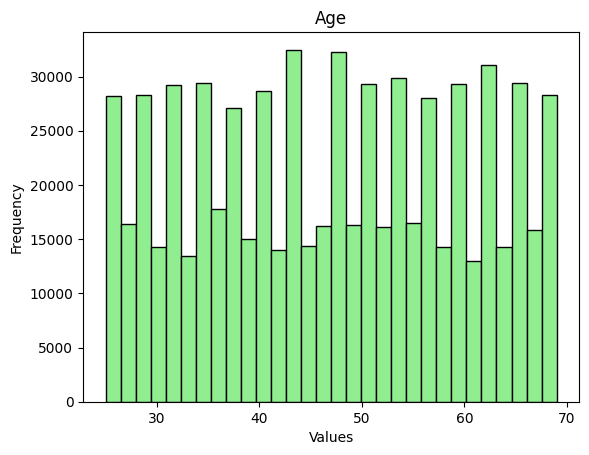

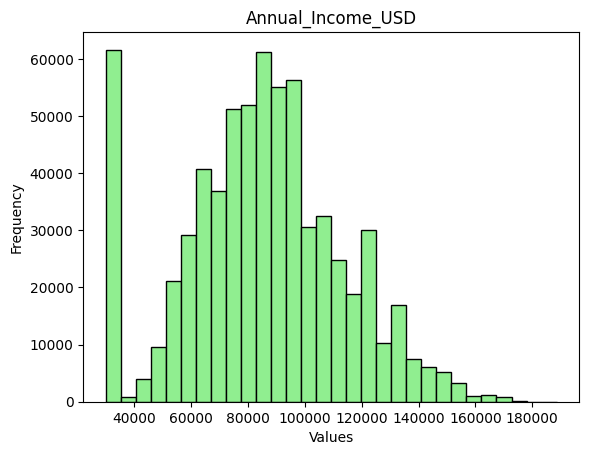

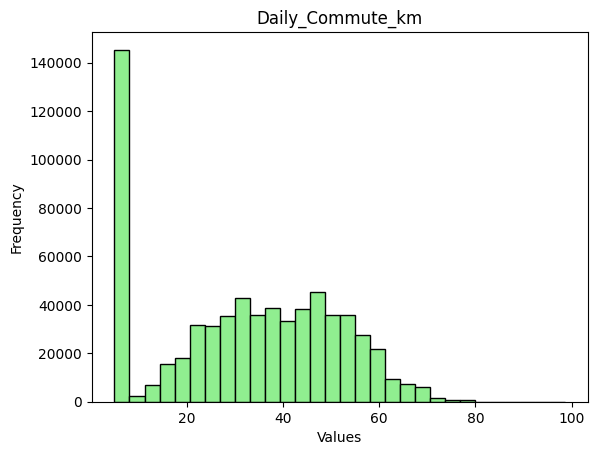

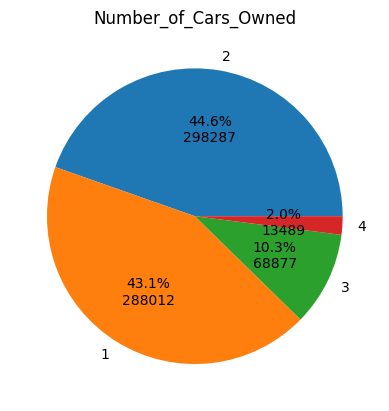

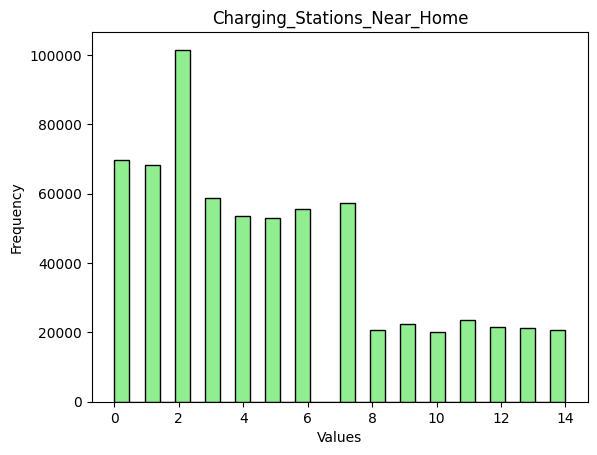

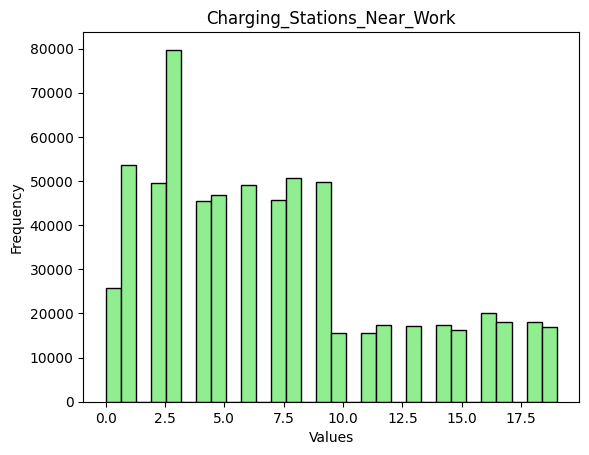

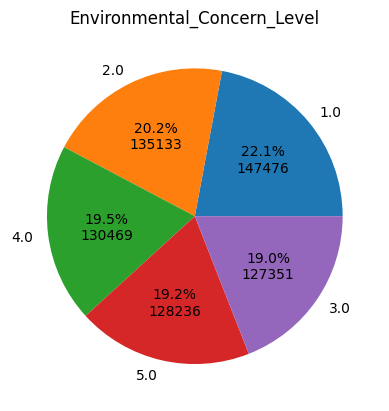

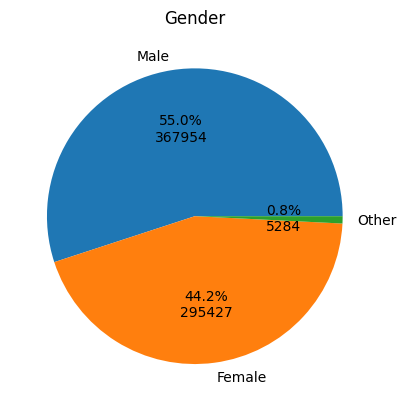

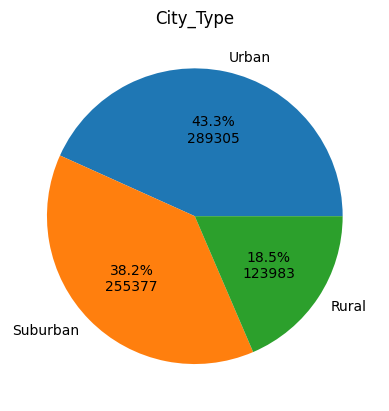

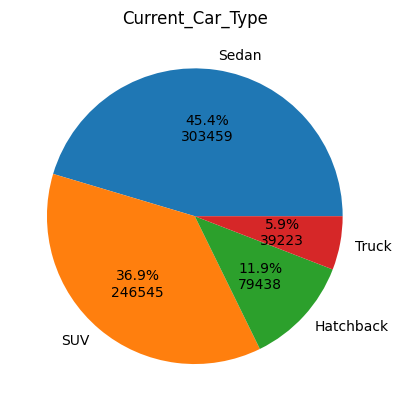

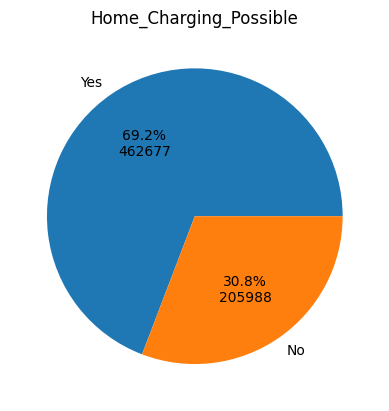

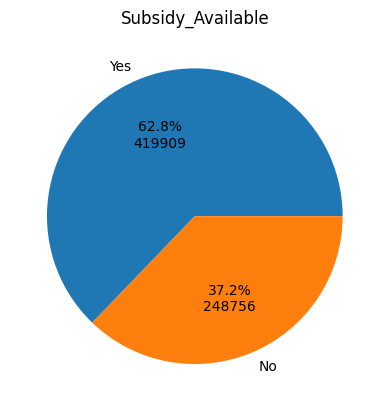

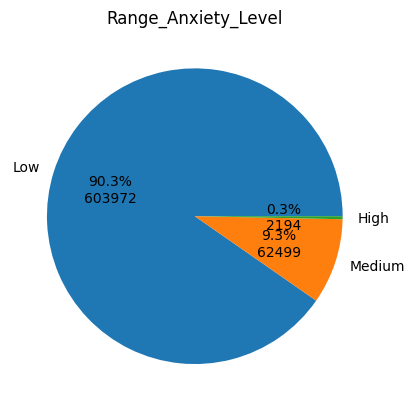

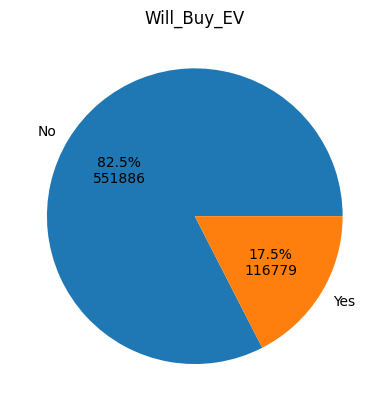

In [16]:
def fmt(x):
            return '{:.1f}%\n{:.0f}'.format(x, total*x/100)

for col in train:
    if train[col].nunique() > 5:
        plt.hist(train[col], bins=30, color='lightgreen', edgecolor='black')
        plt.title(col)
        plt.xlabel('Values')
        plt.ylabel('Frequency')
        plt.show()
    else:
        plt.title(col)
        total = train[col].value_counts().values.sum()
        plt.pie(train[col].value_counts().values, labels=train[col].value_counts().index, autopct=fmt)
        plt.show()

In [17]:
train.Home_Charging_Possible.value_counts()
test.Home_Charging_Possible.value_counts()

Home_Charging_Possible
Yes    198480
No      88091
Name: count, dtype: int64

In [18]:
train.Subsidy_Available.value_counts()
test.Subsidy_Available.value_counts()

Subsidy_Available
Yes    180378
No     106193
Name: count, dtype: int64

In [19]:
# Rename categories
train.Home_Charging_Possible = train.Home_Charging_Possible.replace({'Yes': 'yes_hc', 'No':'no_hc'})
test.Home_Charging_Possible = test.Home_Charging_Possible.replace({'Yes': 'yes_hc', 'No':'no_hc'})

In [20]:
print('Home_Charging_Possible', train.Home_Charging_Possible.unique())
print('Home_Charging_Possible', train.Home_Charging_Possible.nunique())

Home_Charging_Possible ['yes_hc' 'no_hc']
Home_Charging_Possible 2


In [21]:
print('Home_Charging_Possible', test.Home_Charging_Possible.unique())
print('Home_Charging_Possible', test.Home_Charging_Possible.nunique())

Home_Charging_Possible ['yes_hc' 'no_hc']
Home_Charging_Possible 2


In [22]:
# Rename categories
train.Subsidy_Available = train.Subsidy_Available.replace({'Yes': 'yes_sub', 'No':'no_sub'})
test.Subsidy_Available = test.Subsidy_Available.replace({'Yes': 'yes_sub', 'No':'no_sub'})

In [23]:
print('Subsidy_Available', train.Subsidy_Available.unique())
print('Subsidy_Available', train.Subsidy_Available.nunique())

Subsidy_Available ['no_sub' 'yes_sub']
Subsidy_Available 2


In [24]:
print('Subsidy_Available', test.Subsidy_Available.unique())
print('Subsidy_Available', test.Subsidy_Available.nunique())

Subsidy_Available ['no_sub' 'yes_sub']
Subsidy_Available 2


In [25]:
train.Home_Charging_Possible.value_counts()
test.Home_Charging_Possible.value_counts()

Home_Charging_Possible
yes_hc    198480
no_hc      88091
Name: count, dtype: int64

In [26]:
train.Subsidy_Available.value_counts()
test.Subsidy_Available.value_counts()

Subsidy_Available
yes_sub    180378
no_sub     106193
Name: count, dtype: int64

In [27]:
target = train.pop("Will_Buy_EV")
target.head(5), target.tail(5)

(0     No
 1     No
 2    Yes
 3     No
 4     No
 Name: Will_Buy_EV, dtype: object,
 668660    No
 668661    No
 668662    No
 668663    No
 668664    No
 Name: Will_Buy_EV, dtype: object)

In [28]:
le = LabelEncoder()

numeric_target = le.fit_transform(target)
numeric_target[:5],numeric_target[-5:]

(array([0, 0, 1, 0, 0]), array([0, 0, 0, 0, 0]))

In [29]:
cat_cols = [] 
# Iterate through DataFrame columns
for col in train.columns: 
    if train[col].dtype == 'object':  
        # Add the column to the list
        print(col, train[col].unique())
        print(col, train[col].nunique())
        cat_cols.append(col)

Gender ['Male' 'Female' 'Other']
Gender 3
City_Type ['Suburban' 'Rural' 'Urban']
City_Type 3
Current_Car_Type ['Sedan' 'SUV' 'Hatchback' 'Truck']
Current_Car_Type 4
Home_Charging_Possible ['yes_hc' 'no_hc']
Home_Charging_Possible 2
Subsidy_Available ['no_sub' 'yes_sub']
Subsidy_Available 2
Range_Anxiety_Level ['Low' 'Medium' 'High']
Range_Anxiety_Level 3


In [30]:
cat_cols = [] 

In [31]:
for col in test.columns: 
    if test[col].dtype == 'object':  
        # Add the column to the list
        print(col, test[col].unique())
        print(col, test[col].nunique())
        cat_cols.append(col) 

Gender ['Male' 'Female' 'Other']
Gender 3
City_Type ['Suburban' 'Urban' 'Rural']
City_Type 3
Current_Car_Type ['Sedan' 'SUV' 'Hatchback' 'Truck']
Current_Car_Type 4
Home_Charging_Possible ['yes_hc' 'no_hc']
Home_Charging_Possible 2
Subsidy_Available ['no_sub' 'yes_sub']
Subsidy_Available 2
Range_Anxiety_Level ['Low' 'Medium' 'High']
Range_Anxiety_Level 3


In [32]:
num_cols = []

In [33]:
for col in train.columns: 
    if train[col].dtype == 'int' or train[col].dtype == 'float':    
        # Add the column to the list
        num_cols.append(col)     
num_cols

['Age',
 'Annual_Income_USD',
 'Daily_Commute_km',
 'Number_of_Cars_Owned',
 'Charging_Stations_Near_Home',
 'Charging_Stations_Near_Work',
 'Environmental_Concern_Level']

In [34]:
num_cols = []

In [35]:
for col in test.columns: 
    if test[col].dtype == 'int' or test[col].dtype == 'float':    
        # Add the column to the list
        num_cols.append(col)     
num_cols

['Age',
 'Annual_Income_USD',
 'Daily_Commute_km',
 'Number_of_Cars_Owned',
 'Charging_Stations_Near_Home',
 'Charging_Stations_Near_Work',
 'Environmental_Concern_Level']

In [36]:
for col in cat_cols:
    temp = pd.get_dummies(train[col]).astype('int')
    train = pd.concat([train, temp], axis=1)

train.drop(cat_cols, axis=1, inplace=True)
train.shape

(668665, 24)

In [37]:
for col in cat_cols:
    temp = pd.get_dummies(test[col]).astype('int')
    test = pd.concat([test, temp], axis=1)

test.drop(cat_cols, axis=1, inplace=True)
test.shape

(286571, 24)

In [38]:
y = numeric_target
X = train
X_test = test

In [39]:
X_train, X_val, y_train, y_val = train_test_split(X, y, random_state=42, test_size=0.15)
X_train.shape, X_val.shape, y_train.shape, y_val.shape, X_test.shape

((568365, 24), (100300, 24), (568365,), (100300,), (286571, 24))

In [40]:
model = CatBoostClassifier(loss_function='CrossEntropy',iterations=5000, learning_rate=0.1, depth=6, verbose=1000)
# Train the model
model.fit(X_train, y_train)

0:	learn: 0.5378472	total: 136ms	remaining: 11m 21s
1000:	learn: 0.2193822	total: 1m 44s	remaining: 6m 57s
2000:	learn: 0.2125408	total: 3m 23s	remaining: 5m 4s
3000:	learn: 0.2066501	total: 4m 32s	remaining: 3m 1s
4000:	learn: 0.2015013	total: 5m 35s	remaining: 1m 23s
4999:	learn: 0.1968112	total: 6m 37s	remaining: 0us


CatBoostClassifier(depth=6, iterations=5000, learning_rate=0.1, loss_function='CrossEntropy', verbose=1000)

In [41]:
y_pred_proba = model.predict_proba(X_val)[:, 1]
y_pred_proba

array([1.21403271e-02, 3.20431556e-01, 9.24029375e-04, ...,
       4.65908277e-02, 9.26259038e-01, 1.77307901e-03])

In [42]:
# Compute ROC AUC score using probability estimates
roc_auc = roc_auc_score(y_val, y_pred_proba)
print(f"ROC AUC Score: {roc_auc:.2f}")

ROC AUC Score: 0.94


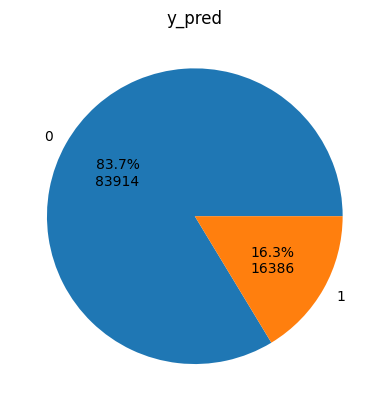

In [43]:
def fmt(x):
    return '{:.1f}%\n{:.0f}'.format(x, total*x/100)

y_pred = pd.Series(model.predict(X_val))


plt.title("y_pred")
total = y_pred.value_counts().values.sum()
plt.pie(y_pred.value_counts().values, labels=y_pred.value_counts().index, autopct=fmt)
plt.show()

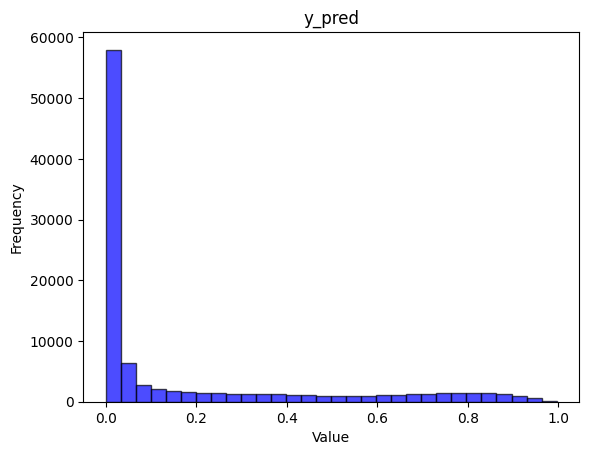

In [44]:
# Create the histogram
plt.hist(y_pred_proba, bins=30, color='blue', edgecolor='black', alpha=0.7)
# Add labels and title
plt.title('y_pred')
plt.xlabel('Value')
plt.ylabel('Frequency')
# Show the plot
plt.show()

In [45]:
# Make predictions
pred_proba = model.predict_proba(X_test)[:, 1]
pred_proba

array([9.53392307e-03, 1.34294964e-02, 2.90462343e-03, ...,
       2.92656065e-03, 5.46092470e-04, 1.08930509e-05])

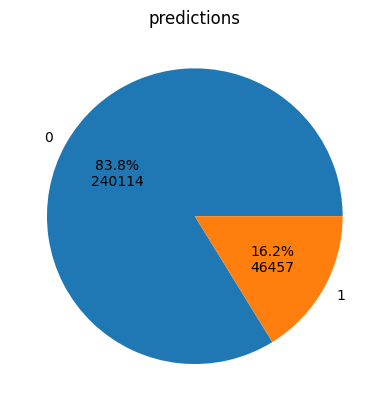

In [46]:
def fmt(x):
    return '{:.1f}%\n{:.0f}'.format(x, total*x/100)

pred = pd.Series(model.predict(X_test))


plt.title("predictions")
total = pred.value_counts().values.sum()
plt.pie(pred.value_counts().values, labels=pred.value_counts().index, autopct=fmt)
plt.show()

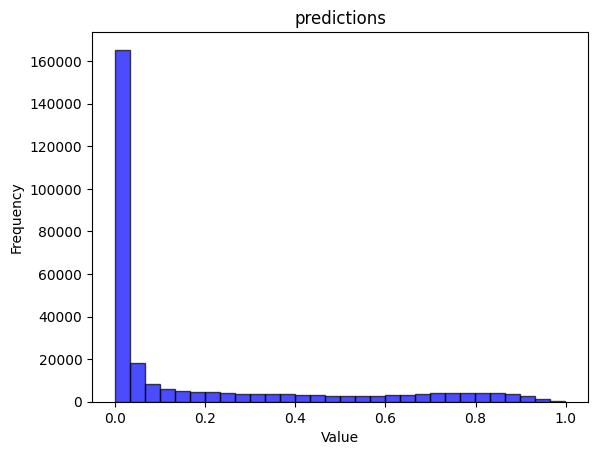

In [47]:
# Create the histogram
plt.hist(pred_proba, bins=30, color='blue', edgecolor='black', alpha=0.7)
# Add labels and title
plt.title('predictions')
plt.xlabel('Value')
plt.ylabel('Frequency')
# Show the plot
plt.show()

In [48]:
submission['Will_Buy_EV'] = pred_proba
submission.to_csv('submission.csv', index=False)
submission = pd.read_csv('submission.csv')
submission

,id,Will_Buy_EV
0,668665,0.009534
1,668666,0.013429
2,668667,0.002905
3,668668,0.002255
4,668669,0.016686
...,...,...
286566,955231,0.000030
286567,955232,0.157248
286568,955233,0.002927
286569,955234,0.000546
